# Multimodal Multi-Label News Classification

**Author: Vittoria Crugnola**

This notebook addresses a multi-input, multi-label classification task.

The model uses:

1. a **text branch**: cleaning, tokenization, vocabulary mapping, padding/truncation, embedding, and LSTM/Bi-LSTM;
2. a **Bag-of-Words branch**: L1 normalization followed by Dense layers;
3. a **metadata branch**: standardized year, one-hot encoded month, and Dense layers;
4. concatenation of the three learned representations;
5. a final `Dense(18, activation="sigmoid")` layer for multi-label prediction.

In [1]:
import os
import gc
import re
import sys
import time
import zipfile
import pickle as pk
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Embedding, LSTM, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    hamming_loss,
    multilabel_confusion_matrix,
    classification_report
)

from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow.keras.backend as K_backend
import random

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

start_time = time.time()  # Track total notebook runtime

SEED = 213

def set_random_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Available devices:", tf.config.list_physical_devices())

TensorFlow version: 2.20.0
Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## Data loading

- `texts[i]`: text of the i-th news article;
- `years[i]`: publication year;
- `months[i]`: publication month;
- `X_bow[i, j]`: absolute frequency of the j-th BoW word in the i-th text;
- `Y[i, j]`: binary target for subject j.

The archive is not distributed in the repository because it contains third-party article text. Locally, it is read from `data/input_data.zip`; in Google Colab, the same archive can be uploaded when requested.

In [2]:
ZIP_CANDIDATES = [
    "../data/input_data.zip",  # notebook launched from the notebooks directory
    "data/input_data.zip",     # notebook launched from the repository directory
    "input_data.zip",
    "/content/input_data.zip",
    "/mnt/data/input_data.zip"
]

ZIP_PATH = next((path for path in ZIP_CANDIDATES if os.path.exists(path)), None)

if ZIP_PATH is None and "google.colab" in sys.modules:
    from google.colab import files

    print("Upload the original input_data.zip archive.")
    uploaded = files.upload()
    ZIP_PATH = next(
        (name for name in uploaded if name.lower().endswith(".zip")),
        None
    )

if ZIP_PATH is None:
    raise FileNotFoundError(
        "input_data.zip was not found. Place it in data/ or upload it in Colab."
    )

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    with zip_ref.open("input_data.pkl") as f:
        data = pk.load(f)

required_keys = {"texts", "years", "months", "X_bow", "labels"}
missing_keys = required_keys.difference(data)
if missing_keys:
    raise KeyError(f"The dataset is missing the following keys: {sorted(missing_keys)}")

texts = data["texts"]
years = data["years"]
months = data["months"]
X_bow_full = data["X_bow"]
Y_full = data["labels"]

print("Dataset archive:", ZIP_PATH)
print("Number of samples:", len(texts))
print("X_bow shape:", X_bow_full.shape, X_bow_full.dtype)
print("Y shape:", Y_full.shape, Y_full.dtype)
print("Labels per sample: min =", Y_full.sum(axis=1).min(),
      "max =", Y_full.sum(axis=1).max(),
      "mean =", Y_full.sum(axis=1).mean())

Dataset archive: ../data/input_data.zip
Number of samples: 11000
X_bow shape: (11000, 10000) int64
Y shape: (11000, 18) int64
Labels per sample: min = 2 max = 3 mean = 2.272727272727273


## 1. MODEL CHOICE

The task is to predict one or more categories for each news entry from three available input fields: raw text, Bag-of-Words, and metadata.

A **multi-input neural network** with three separate branches preserves the specific structure of each input type before combining them:

- raw text is sequential, so it is processed with an embedding layer and an LSTM or Bi-LSTM;
- the BoW vector is a fixed-size numerical representation, so it is processed with Dense layers;
- metadata contains structured features, so it is processed with Dense layers.

The three learned representations are concatenated and passed to shared Dense layers for the final multi-label prediction.

## 2. INPUT

### 2.a How to preprocess input data

The three input fields are preprocessed separately.

A stratified train/validation/test split is created first, so preprocessing decisions are based on the training set only and data leakage is avoided.

All 11,000 available samples are retained. The split is stratified by the complete label vector so that every observed label combination is represented proportionally in the training, validation, and test sets.

In [3]:
# Split data
K = 18

all_indices = np.arange(len(texts))

# Stratify using the whole label vector
label_patterns = np.array(["".join(row.astype(str)) for row in Y_full])

idx_train, idx_temp = train_test_split(
    all_indices,
    test_size=0.30,
    random_state=SEED,
    stratify=label_patterns
)

idx_val, idx_test = train_test_split(
    idx_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=label_patterns[idx_temp]
)

Y_train = Y_full[idx_train].astype("float32")
Y_val = Y_full[idx_val].astype("float32")
Y_test = Y_full[idx_test].astype("float32")

print("Train size:", len(idx_train))
print("Validation size:", len(idx_val))
print("Test size:", len(idx_test))

def print_split_info(name, y):
    print(f"\n{name}")
    print("shape:", y.shape)
    print("labels per sample: min =", y.sum(axis=1).min(),
          "max =", y.sum(axis=1).max(),
          "mean =", y.sum(axis=1).mean())
    print("per-label positive counts:", y.sum(axis=0).astype(int))

print_split_info("TRAIN", Y_train)       # 70%
print_split_info("VALIDATION", Y_val)    # 15%
print_split_info("TEST", Y_test)         # 15%

Train size: 7700
Validation size: 1650
Test size: 1650

TRAIN
shape: (7700, 18)
labels per sample: min = 2.0 max = 3.0 mean = 2.2727273
per-label positive counts: [ 700  700  700  700  700  700  700 1400  700 2800 1400  700 1400  700
  700  700  700 1400]

VALIDATION
shape: (1650, 18)
labels per sample: min = 2.0 max = 3.0 mean = 2.2727273
per-label positive counts: [150 150 150 150 150 150 150 300 150 600 300 150 300 150 150 150 150 300]

TEST
shape: (1650, 18)
labels per sample: min = 2.0 max = 3.0 mean = 2.2727273
per-label positive counts: [150 150 150 150 150 150 150 300 150 600 300 150 300 150 150 150 150 300]


### Text preprocessing

1. lowercase;
2. remove punctuation and symbols;
3. split into individual words (tokens);
4. build the vocabulary on the training set only;
5. map each token to an integer index;
6. pad shorter sequences and truncate longer sequences to a fixed length;
7. feed the integer sequence to an Embedding layer.

`MAX_SEQ_LEN` controls the maximum number of tokens retained for each text. The dataset has an average length of about 28 words, while almost all entries contain fewer than 80 words. A length of 80 therefore preserves nearly all available text without adding unnecessary padding.

In [4]:
# Text preprocessing

VOCAB_SIZE = 20000  # maximum vocabulary size
MAX_SEQ_LEN = 80     # baseline value of L
PAD_IDX = 0          # padding token
OOV_IDX = 1          # unknown, out-of-vocabulary token

def clean_and_tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z ]+", " ", text)
    tokens = text.split()
    return tokens

texts_train = [texts[i] for i in idx_train]
texts_val = [texts[i] for i in idx_val]
texts_test = [texts[i] for i in idx_test]

# Build vocabulary using the training set only
counter = Counter()
for text in texts_train:
    counter.update(clean_and_tokenize(text))

# Keep only the most frequent words
most_common_words = [
    word for word, count in counter.most_common(VOCAB_SIZE - 2)
]

# Each word is mapped to an integer index
word_to_index = {"<PAD>": PAD_IDX, "<OOV>": OOV_IDX}
for pos, word in enumerate(most_common_words, start=2):
    word_to_index[word] = pos

actual_vocab_size = len(word_to_index)
print("Actual vocabulary size:", actual_vocab_size)

def texts_to_sequences(text_list, word_to_index, max_len):
    X = np.zeros((len(text_list), max_len), dtype="int32")

    for i, text in enumerate(text_list):
        tokens = clean_and_tokenize(text)
        token_ids = [word_to_index.get(token, OOV_IDX) for token in tokens]
        token_ids = token_ids[:max_len]
        X[i, :len(token_ids)] = token_ids

    return X

def prepare_text_data(max_seq_len):  # L is a hyperparameter
    X_text_train_tuned = texts_to_sequences(
        texts_train,
        word_to_index,
        max_len=max_seq_len
    )

    X_text_val_tuned = texts_to_sequences(
        texts_val,
        word_to_index,
        max_len=max_seq_len
    )

    X_text_test_tuned = texts_to_sequences(
        texts_test,
        word_to_index,
        max_len=max_seq_len
    )

    return X_text_train_tuned, X_text_val_tuned, X_text_test_tuned

# Baseline
X_text_train_tuned, X_text_val_tuned, X_text_test_tuned = prepare_text_data(MAX_SEQ_LEN)

print("Text input shape:", X_text_train_tuned.shape)
print("Example encoded sequence:", X_text_train_tuned[0][:20])

Actual vocabulary size: 20000
Text input shape: (7700, 80)
Example encoded sequence: [ 385 1626    5  887  143  123  206 2630   27 3484    4 2631 2856 2632
  888    5  604   96  308    0]


### Bag-of-Words preprocessing

The BoW input is a fixed-size vector ($d = 10000$), where each component is an absolute word frequency.

Each row is normalized into relative frequencies:

$$
X'_{ij} = \frac{X_{ij}}{\sum_{j=1}^{d} X_{ij}}.
$$

This makes entries of different lengths more comparable.

The original 10,000-dimensional representation is retained. This preserves every supplied BoW feature and keeps the preprocessing consistent with the model design. The full matrix is converted to `float32` only after the train/validation/test split to control memory usage.

In [5]:
# BoW preprocessing

X_bow_train = X_bow_full[idx_train].astype("float32")
X_bow_val = X_bow_full[idx_val].astype("float32")
X_bow_test = X_bow_full[idx_test].astype("float32")

# L1 normalization
def normalize_bow_rows(X):
    row_sum = X.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1.0
    return X / row_sum

X_bow_train = normalize_bow_rows(X_bow_train)
X_bow_val = normalize_bow_rows(X_bow_val)
X_bow_test = normalize_bow_rows(X_bow_test)

BOW_DIM = X_bow_train.shape[1]

# Free the original dense matrix after the split arrays are extracted
del X_bow_full
del data
gc.collect()

print("BoW input shape:", X_bow_train.shape)
print("BoW dimension:", BOW_DIM)

BoW input shape: (7700, 10000)
BoW dimension: 10000


### Metadata preprocessing

The metadata consists of publication year and publication month.

- Year is numerical, so it is standardized with the training-set mean and standard deviation.
- Month is categorical, so it is one-hot encoded into 12 binary components.

The resulting metadata vector has dimension $1 + 12 = 13$.

In [6]:
# Metadata preprocessing

metadata_raw = np.column_stack([
    np.asarray(years),
    np.asarray(months)
])

metadata_train = metadata_raw[idx_train]
metadata_val = metadata_raw[idx_val]
metadata_test = metadata_raw[idx_test]

try:
    month_encoder = OneHotEncoder(  #one hot encode month
        categories=[np.arange(1, 13)],
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    month_encoder = OneHotEncoder(
        categories=[np.arange(1, 13)],
        handle_unknown="ignore",
        sparse=False
    )

metadata_preprocessor = ColumnTransformer(
    transformers=[
        ("year_scaler", StandardScaler(), [0]), #standardise year
        ("month_encoder", month_encoder, [1])
    ]
)

# Fit only on the training set
X_meta_train = metadata_preprocessor.fit_transform(metadata_train)
X_meta_val = metadata_preprocessor.transform(metadata_val)
X_meta_test = metadata_preprocessor.transform(metadata_test)

X_meta_train = X_meta_train.astype("float32")
X_meta_val = X_meta_val.astype("float32")
X_meta_test = X_meta_test.astype("float32")

META_DIM = X_meta_train.shape[1]

print("Metadata train shape:", X_meta_train.shape)
print("Metadata validation shape:", X_meta_val.shape)
print("Metadata test shape:", X_meta_test.shape)

Metadata train shape: (7700, 13)
Metadata validation shape: (1650, 13)
Metadata test shape: (1650, 13)


### 2.b Model inputs and representation

In [7]:
# Final input shapes after preprocessing

print("Text train shape:", X_text_train_tuned.shape)
print("BoW train shape:", X_bow_train.shape)
print("Metadata train shape:", X_meta_train.shape)
print("Target train shape:", Y_train.shape)

Text train shape: (7700, 80)
BoW train shape: (7700, 10000)
Metadata train shape: (7700, 13)
Target train shape: (7700, 18)


## 3. OUTPUT AND LOSS

The targets are represented as a binary matrix:

$$
Y \in \{0,1\}^{N \times 18}.
$$

Each news entry can be associated with more than one subject. Therefore, this is **multi-label classification**.

The output layer is:

$$
\mathrm{Dense}(18, \sigma),
$$

where each sigmoid output estimates the probability that one subject is present.

The appropriate loss is Binary Cross-Entropy. Softmax is not appropriate because the labels are not mutually exclusive.

## 4. MODEL CONFIGURATION

### 4.a Graphical sketch

```text
text sequence -> Embedding -> LSTM/Bi-LSTM --------------------
                                                               |
BoW vector -> L1 norm -> Dense + ReLU -------------------------|-> Concatenate -> Dense + ReLU -> Dense(18) + Sigmoid
                                                               |
metadata vector -> preprocessing -> Dense + ReLU --------------
```

### 4.b Configuration and optimization


### Hyperparameter tuning

The following quantities are treated as hyperparameters and selected using the validation set:

- L: maximum text sequence length;
- d: embedding dimension;
- B: batch size;
- p: dropout rate;
- $\lambda$: L2 regularization strength;
- patience for early stopping;
- maximum number of epochs;
- optimizer and initial learning rate $\eta$;
- learning-rate reduction factor and patience;
- number and size of Dense layers;
- LSTM or Bidirectional LSTM in the text branch;
- number of recurrent layers and recurrent units;
- gradient clipping threshold;
- position where dropout is inserted.

The validation search is intentionally compact. It retains the original architecture and varies only a small set of influential choices, reducing unnecessary experimentation while still comparing meaningful alternatives.

In [8]:
# Hyperparameter search space

search_space = {
    "max_seq_len": [64, 80],          # L
    "embedding_dim": [64],            # d
    "batch_size": [64],               # B
    "dropout_rate": [0.20, 0.25, 0.30],  # p
    "l2_strength": [1e-5, 1e-4],      # lambda
    "epochs": [25],
    "patience": [5],
    "optimizer_name": ["adam"],
    "learning_rate": [1e-3],
    "lr_decay_factor": [0.5],
    "lr_decay_after_epochs": [2],
    "bow_num_dense_layers": [1],
    "bow_dense_units": [64, 128],
    "meta_num_dense_layers": [1],
    "meta_dense_units": [32],
    "shared_num_dense_layers": [1],
    "shared_dense_units": [128],
    "recurrent_type": ["bilstm"],
    "num_recurrent_layers": [1],
    "recurrent_units": [64],
    "dropout_position": ["all"],
    "clipnorm": [1.0]
}

In [9]:
def get_optimizer(optimizer_name, learning_rate, clipnorm):
    if optimizer_name == "adam":
        return Adam(learning_rate=learning_rate, clipnorm=clipnorm)

    if optimizer_name == "rmsprop":
        return RMSprop(learning_rate=learning_rate, clipnorm=clipnorm)

    if optimizer_name == "sgd":
        return SGD(learning_rate=learning_rate, clipnorm=clipnorm)

    raise ValueError("Unknown optimizer")

In [10]:
def make_lr_scheduler(lr_decay_factor, lr_decay_after_epochs):
    return ReduceLROnPlateau(
        monitor="val_loss",
        factor=lr_decay_factor,
        patience=lr_decay_after_epochs,
        min_lr=1e-6
    )

Build model

In [11]:
def build_model(config):
    K_backend.clear_session()
    set_random_seed(SEED)
    max_seq_len = config["max_seq_len"]
    embedding_dim = config["embedding_dim"]
    recurrent_type = config["recurrent_type"]
    recurrent_units = config["recurrent_units"]
    num_recurrent_layers = config["num_recurrent_layers"]
    bow_num_dense_layers = config["bow_num_dense_layers"]
    bow_dense_units = config["bow_dense_units"]
    meta_num_dense_layers = config["meta_num_dense_layers"]
    meta_dense_units = config["meta_dense_units"]
    shared_num_dense_layers = config["shared_num_dense_layers"]
    shared_dense_units = config["shared_dense_units"]
    dropout_rate = config["dropout_rate"]
    dropout_position = config["dropout_position"]
    l2_strength = config["l2_strength"]
    optimizer_name = config["optimizer_name"]
    learning_rate = config["learning_rate"]
    clipnorm = config["clipnorm"]

    # Text branch
    text_input = Input(
        shape=(max_seq_len,),
        dtype="int32",
        name="text_input"
    )

    text_features = Embedding(
        input_dim=actual_vocab_size,
        output_dim=embedding_dim,
        mask_zero=True,
        name="text_embedding"
    )(text_input)


    for layer_idx in range(num_recurrent_layers):
        return_sequences = layer_idx < num_recurrent_layers - 1
        lstm_layer = LSTM(
            recurrent_units,
            return_sequences=return_sequences,
            kernel_regularizer=regularizers.L2(l2_strength),
            name=f"lstm_layer_{layer_idx + 1}"
        )

        if recurrent_type == "lstm":
            text_features = lstm_layer(text_features)
        elif recurrent_type == "bilstm":
            text_features = Bidirectional(
                lstm_layer,
                name=f"bilstm_layer_{layer_idx + 1}"
            )(text_features)

        else:
            raise ValueError("recurrent_type must be 'lstm' or 'bilstm'")

    if dropout_position in ["branches", "all"]:
        text_features = Dropout(
            dropout_rate,
            name="text_dropout"
        )(text_features)

    # BoW branch
    bow_input = Input(
        shape=(BOW_DIM,),
        dtype="float32",
        name="bow_input"
    )

    bow_features = bow_input
    for layer_idx in range(bow_num_dense_layers):
        bow_features = Dense(
            bow_dense_units,
            activation="relu",
            kernel_initializer="he_normal",
            kernel_regularizer=regularizers.L2(l2_strength),
            name=f"bow_dense_{layer_idx + 1}"
        )(bow_features)

        if dropout_position in ["branches", "all"]:
            bow_features = Dropout(
                dropout_rate,
                name=f"bow_dropout_{layer_idx + 1}"
            )(bow_features)

    # Metadata branch
    metadata_input = Input(
        shape=(META_DIM,),
        dtype="float32",
        name="metadata_input"
    )

    metadata_features = metadata_input
    for layer_idx in range(meta_num_dense_layers):
        metadata_features = Dense(
            meta_dense_units,
            activation="relu",
            kernel_initializer="he_normal",
            kernel_regularizer=regularizers.L2(l2_strength),
            name=f"metadata_dense_{layer_idx + 1}"
        )(metadata_features)

    # The metadata vector contains only 13 features, so it is kept complete.

    # Concatenation

    features = Concatenate(name="concatenation")(
        [text_features, bow_features, metadata_features]
    )

    # Shared dense layers
    for layer_idx in range(shared_num_dense_layers):

        features = Dense(
            shared_dense_units,
            activation="relu",
            kernel_initializer="he_normal",
            kernel_regularizer=regularizers.L2(l2_strength),
            name=f"shared_dense_{layer_idx + 1}"
        )(features)

        if dropout_position in ["shared", "all"]:
            features = Dropout(
                dropout_rate,
                name=f"shared_dropout_{layer_idx + 1}"
            )(features)


    # Output layer
    output = Dense(
        K,
        activation="sigmoid",
        name="label_output"
    )(features)

    model = Model(
        inputs=[text_input, bow_input, metadata_input],
        outputs=output,
        name="multi_input_multilabel_news_classifier"
    )

    model.compile(
        optimizer=get_optimizer(
            optimizer_name=optimizer_name,
            learning_rate=learning_rate,
            clipnorm=clipnorm
        ),
        loss="binary_crossentropy"
    )

    return model

Reference configuration

In [12]:
baseline_config = {
    "max_seq_len": 80,
    "embedding_dim": 64,
    "recurrent_type": "bilstm",
    "recurrent_units": 64,
    "num_recurrent_layers": 1,
    "bow_num_dense_layers": 1,
    "bow_dense_units": 128,
    "meta_num_dense_layers": 1,
    "meta_dense_units": 32,
    "shared_num_dense_layers": 1,
    "shared_dense_units": 128,
    "dropout_rate": 0.25,
    "dropout_position": "all",
    "l2_strength": 1e-5,
    "optimizer_name": "adam",
    "learning_rate": 1e-3,
    "lr_decay_factor": 0.5,
    "lr_decay_after_epochs": 2,
    "batch_size": 64,
    "epochs": 25,
    "patience": 5,
    "clipnorm": 1.0
}

model = build_model(baseline_config)
model.summary()

Model: "multi_input_multilabel_news_classifier"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 80)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_embedding      │ (None, 80, 64)    │  1,280,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 80)        │          0 │ text_input[0][0]  │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bow_input           │ (Non

In [13]:
# Hyperparameter tuning on the validation set

def sample_config(search_space, rng):  # Randomly sample one hyperparameter configuration
    return {
        key: rng.choice(values)
        for key, values in search_space.items()
    }

N_TRIALS = 2
rng = random.Random(SEED)

configs = []
configs.append(baseline_config)

# Add randomly sampled configurations
for i in range(N_TRIALS):
    configs.append(sample_config(search_space, rng))

results = []

for trial_id, config in enumerate(configs):
    print("\n====================================")
    print("Trial:", trial_id)
    print(config)

    K_backend.clear_session()
    set_random_seed(SEED)

    # Recreate the text sequences using the current value of max_seq_len
    X_text_train_tuned, X_text_val_tuned, X_text_test_tuned = prepare_text_data(
        max_seq_len=config["max_seq_len"]
    )

    model = build_model(config)  # Build model

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=config["patience"],
        restore_best_weights=True
    )

    lr_scheduler = make_lr_scheduler(
        lr_decay_factor=config["lr_decay_factor"],
        lr_decay_after_epochs=config["lr_decay_after_epochs"]
    )

    history = model.fit(
        [X_text_train_tuned, X_bow_train, X_meta_train],
        Y_train,
        validation_data=(
            [X_text_val_tuned, X_bow_val, X_meta_val],
            Y_val
        ),
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        callbacks=[early_stopping, lr_scheduler],
        verbose=0
    )

    # Validation predictions
    val_prob = model.predict(
        [X_text_val_tuned, X_bow_val, X_meta_val],
        verbose=0
    )

    threshold = 0.5
    val_pred = (val_prob >= threshold).astype(int)

    val_macro_f1 = f1_score(
        Y_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    result = config.copy()
    result["trial_id"] = trial_id
    result["val_macro_f1"] = val_macro_f1
    result["best_val_loss"] = min(history.history["val_loss"])
    result["actual_epochs"] = len(history.history["loss"])

    results.append(result)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="val_macro_f1",
    ascending=False
)

results_df[
    [
        "trial_id", "max_seq_len", "dropout_rate", "l2_strength",
        "bow_dense_units", "val_macro_f1", "best_val_loss", "actual_epochs"
    ]
]


Trial: 0
{'max_seq_len': 80, 'embedding_dim': 64, 'recurrent_type': 'bilstm', 'recurrent_units': 64, 'num_recurrent_layers': 1, 'bow_num_dense_layers': 1, 'bow_dense_units': 128, 'meta_num_dense_layers': 1, 'meta_dense_units': 32, 'shared_num_dense_layers': 1, 'shared_dense_units': 128, 'dropout_rate': 0.25, 'dropout_position': 'all', 'l2_strength': 1e-05, 'optimizer_name': 'adam', 'learning_rate': 0.001, 'lr_decay_factor': 0.5, 'lr_decay_after_epochs': 2, 'batch_size': 64, 'epochs': 25, 'patience': 5, 'clipnorm': 1.0}

Trial: 1
{'max_seq_len': 64, 'embedding_dim': 64, 'batch_size': 64, 'dropout_rate': 0.25, 'l2_strength': 1e-05, 'epochs': 25, 'patience': 5, 'optimizer_name': 'adam', 'learning_rate': 0.001, 'lr_decay_factor': 0.5, 'lr_decay_after_epochs': 2, 'bow_num_dense_layers': 1, 'bow_dense_units': 128, 'meta_num_dense_layers': 1, 'meta_dense_units': 32, 'shared_num_dense_layers': 1, 'shared_dense_units': 128, 'recurrent_type': 'bilstm', 'num_recurrent_layers': 1, 'recurrent_unit

In [14]:
# Select the best hyperparameter configuration

best_idx = results_df["val_macro_f1"].idxmax()
best_config = {
    key: results_df.loc[best_idx, key]
    for key in baseline_config
}

integer_parameters = [
    "max_seq_len", "embedding_dim", "recurrent_units",
    "num_recurrent_layers", "bow_num_dense_layers", "bow_dense_units",
    "meta_num_dense_layers", "meta_dense_units", "shared_num_dense_layers",
    "shared_dense_units", "lr_decay_after_epochs", "batch_size", "epochs",
    "patience"
]
for parameter in integer_parameters:
    best_config[parameter] = int(best_config[parameter])

print("Best hyperparameter configuration:")
for key, value in best_config.items():
    print(key, ":", value)

Best hyperparameter configuration:
max_seq_len : 80
embedding_dim : 64
recurrent_type : bilstm
recurrent_units : 64
num_recurrent_layers : 1
bow_num_dense_layers : 1
bow_dense_units : 128
meta_num_dense_layers : 1
meta_dense_units : 32
shared_num_dense_layers : 1
shared_dense_units : 128
dropout_rate : 0.25
dropout_position : all
l2_strength : 1e-05
optimizer_name : adam
learning_rate : 0.001
lr_decay_factor : 0.5
lr_decay_after_epochs : 2
batch_size : 64
epochs : 25
patience : 5
clipnorm : 1.0


In [15]:
# Build final model

K_backend.clear_session()
set_random_seed(SEED)

X_text_train_best, X_text_val_best, X_text_test_best = prepare_text_data(
    max_seq_len=best_config["max_seq_len"]
)

best_model = build_model(best_config)
best_model.summary()

Model: "multi_input_multilabel_news_classifier"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 80)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_embedding      │ (None, 80, 64)    │  1,280,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 80)        │          0 │ text_input[0][0]  │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bow_input           │ (Non

## 5. MODEL EVALUATION

The selected configuration is trained with early stopping and evaluated once on the untouched test set.

Decision thresholds are selected independently for each label using validation data only. Results are shown both for the standard threshold of 0.5 and for the validation-tuned thresholds.

The reported measures are:

1. test Binary Cross-Entropy loss;
2. macro precision and recall;
3. macro, micro, and weighted F1-score;
4. exact-match accuracy and Hamming accuracy;
5. classification report and one confusion matrix per label.

Epoch 1/25
121/121 - 7s - 61ms/step - loss: 0.3913 - val_loss: 0.3247 - learning_rate: 0.0010
Epoch 2/25
121/121 - 4s - 34ms/step - loss: 0.3115 - val_loss: 0.2809 - learning_rate: 0.0010
Epoch 3/25
121/121 - 4s - 36ms/step - loss: 0.2369 - val_loss: 0.2412 - learning_rate: 0.0010
Epoch 4/25
121/121 - 4s - 36ms/step - loss: 0.1488 - val_loss: 0.2318 - learning_rate: 0.0010
Epoch 5/25
121/121 - 4s - 34ms/step - loss: 0.0828 - val_loss: 0.2301 - learning_rate: 0.0010
Epoch 6/25
121/121 - 4s - 35ms/step - loss: 0.0469 - val_loss: 0.2657 - learning_rate: 0.0010
Epoch 7/25
121/121 - 4s - 36ms/step - loss: 0.0321 - val_loss: 0.2720 - learning_rate: 0.0010
Epoch 8/25
121/121 - 5s - 38ms/step - loss: 0.0201 - val_loss: 0.2855 - learning_rate: 5.0000e-04
Epoch 9/25
121/121 - 4s - 34ms/step - loss: 0.0149 - val_loss: 0.3121 - learning_rate: 5.0000e-04
Epoch 10/25
121/121 - 5s - 39ms/step - loss: 0.0124 - val_loss: 0.3160 - learning_rate: 2.5000e-04
Validation-selected thresholds:
[0.5  0.2  0.55

,macro_precision,macro_recall,macro_f1,micro_f1,weighted_f1,exact_match_accuracy,hamming_accuracy
threshold_0.50,0.7320,0.5868,0.6442,0.6824,0.6774,0.5067,0.9263
validation_tuned,0.6731,0.6471,0.6558,0.6844,0.6842,0.5055,0.9215


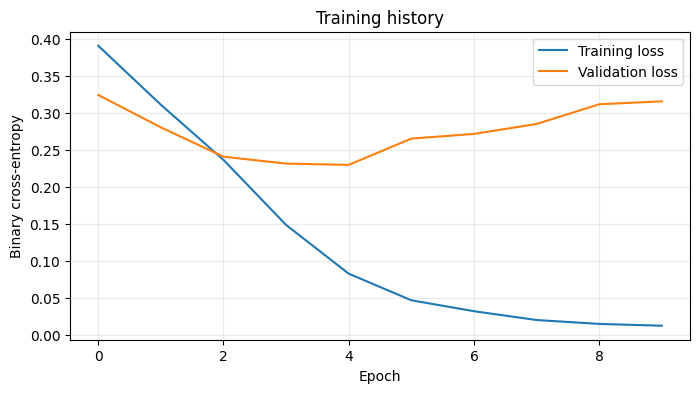

In [16]:
# Model evaluation

# Train selected model
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=best_config["patience"],
    restore_best_weights=True
)

lr_scheduler = make_lr_scheduler(
    lr_decay_factor=best_config["lr_decay_factor"],
    lr_decay_after_epochs=best_config["lr_decay_after_epochs"]
)

history = best_model.fit(
    [X_text_train_best, X_bow_train, X_meta_train],
    Y_train,
    validation_data=(
        [X_text_val_best, X_bow_val, X_meta_val],
        Y_val
    ),
    epochs=best_config["epochs"],
    batch_size=best_config["batch_size"],
    callbacks=[early_stopping, lr_scheduler],
    verbose=2
)

# Select one decision threshold per label using validation data only
Y_val_prob = best_model.predict(
    [X_text_val_best, X_bow_val, X_meta_val],
    verbose=0
)

threshold_grid = np.arange(0.10, 0.91, 0.05)
thresholds = np.full(K, 0.5, dtype="float32")

for label_idx in range(K):
    label_scores = [
        f1_score(
            Y_val[:, label_idx],
            Y_val_prob[:, label_idx] >= threshold,
            zero_division=0
        )
        for threshold in threshold_grid
    ]
    thresholds[label_idx] = threshold_grid[int(np.argmax(label_scores))]

print("Validation-selected thresholds:")
print(np.round(thresholds, 2))

# Test BCE
test_loss = best_model.evaluate(
    [X_text_test_best, X_bow_test, X_meta_test],
    Y_test,
    verbose=0
)

print("Test binary cross-entropy:", test_loss)

Y_test_prob = best_model.predict(  # probabilities
    [X_text_test_best, X_bow_test, X_meta_test],
    verbose=0
)

Y_test_pred_05 = (Y_test_prob >= 0.5).astype(int)
Y_test_pred = (Y_test_prob >= thresholds).astype(int)

def evaluation_summary(y_true, y_pred):
    return {
        "macro_precision": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "macro_recall": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "macro_f1": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "micro_f1": f1_score(
            y_true, y_pred, average="micro", zero_division=0
        ),
        "weighted_f1": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "exact_match_accuracy": accuracy_score(y_true, y_pred),
        "hamming_accuracy": 1.0 - hamming_loss(y_true, y_pred)
    }

comparison_df = pd.DataFrame(
    {
        "threshold_0.50": evaluation_summary(Y_test, Y_test_pred_05),
        "validation_tuned": evaluation_summary(Y_test, Y_test_pred)
    }
).T

print("\nTest metrics:")
display(comparison_df.round(4))

print("\nClassification report with validation-tuned thresholds:")
print(
    classification_report(
        Y_test,
        Y_test_pred,
        target_names=[f"label_{i}" for i in range(K)],
        zero_division=0
    )
)

conf_matrices = multilabel_confusion_matrix(  # one confusion matrix per label
    Y_test,
    Y_test_pred
)

for label_idx, cm in enumerate(conf_matrices):
    print(f"\nConfusion matrix for label {label_idx}:")
    print(cm)

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.title("Training history")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [17]:
end_time = time.time()
elapsed_time = end_time - start_time

print(f"Total runtime: {elapsed_time / 60:.1f} minutes")

Total runtime: 3.2 minutes


The final model retains the original three-branch design while training on every available sample. Validation-driven early stopping limits overfitting, and per-label threshold selection improves the balance between precision and recall without using information from the test set.